# Direction of Project Analysis
## From Analytics to Action — DTU Spring 2026

We are **lightly exploring some directions** to take for our project. The goal here is not a deep analysis — it is to quickly test whether each direction has enough signal, richness, and course-framework alignment to justify a full deep-dive.

**Format:** Each section runs a quick analysis, states findings, and ends with a **Verdict** — should we pursue this direction?

**Dataset:** 2,000 European movies from IMDb (23 columns)
**Case company:** Publikum

---

### Directions we explore

1. Keywords → Rating
2. Actor/Actress Combinations → Rating
3. What Makes a Film "Travel"? (Breakout Analysis)
4. Plot-Based Thematic Clustering (NLP)
5. Genre White Space Analysis
6. Language and Market Reach
7. Co-Production Success by Country Pair
8. Director Talent Patterns

In [1]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from collections import Counter
from itertools import combinations
import re
import os
import warnings
warnings.filterwarnings('ignore')

# Change to project root
os.chdir(os.path.join(os.path.dirname(os.path.abspath('.')), ''))
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

os.makedirs('reports/figures', exist_ok=True)

# Project utilities
from src.visualize import set_style, save_figure

set_style()
print(f"Working directory: {os.getcwd()}")

Working directory: /Users/jep/Desktop/DTU/from-analytics-to-action


In [2]:
# Load dataset
df = pd.read_excel('03-data/European_data_2000.xlsx')

def split_field(series, sep=', '):
    """Split a comma-separated string column into a flat list of individual values."""
    return series.dropna().str.split(sep).explode().str.strip()

# Derived columns
df['genre_count'] = df['genres'].str.split(', ').apply(lambda x: len(x) if isinstance(x, list) else 0)
df['country_count'] = df['allCountries'].str.split(', ').apply(lambda x: len(x) if isinstance(x, list) else 0)
df['is_coproduction'] = df['country_count'] > 1
df['keyword_count'] = df['keywords'].str.split(', ').apply(lambda x: len(x) if isinstance(x, list) else 0)
df['language_count'] = df['allLanguages'].str.split(', ').apply(lambda x: len(x) if isinstance(x, list) else 0)

overall_mean_rating = df['imdbRating'].mean()
overall_median_rating = df['imdbRating'].median()
overall_median_votes = df['numberOfVotes'].median()

print(f"Loaded {len(df):,} movies")
print(f"Mean rating: {overall_mean_rating:.2f} | Median rating: {overall_median_rating:.2f}")
print(f"Median votes: {overall_median_votes:,.0f}")

Loaded 2,000 movies
Mean rating: 6.39 | Median rating: 6.50
Median votes: 11,769


---

## 1. Keywords → Rating

**Question:** Are certain keywords associated with higher or lower IMDb ratings?

Keywords are user-contributed tags on IMDb — things like "murder", "family secret", "coming of age". If some keywords reliably predict higher ratings, that tells us something about what thematic choices resonate with audiences.

In [3]:
# For each keyword appearing in 20+ films, compute mean rating
all_keywords = split_field(df['keywords'])
keyword_freq = all_keywords.value_counts()
common_keywords = keyword_freq[keyword_freq >= 20].index

keyword_stats = []
for kw in common_keywords:
    mask = df['keywords'].str.contains(re.escape(kw), na=False, case=False)
    ratings = df.loc[mask, 'imdbRating']
    keyword_stats.append({
        'keyword': kw,
        'frequency': mask.sum(),
        'mean_rating': ratings.mean(),
        'delta': ratings.mean() - overall_mean_rating
    })

kw_df = pd.DataFrame(keyword_stats).sort_values('mean_rating', ascending=False)
print(f"Keywords appearing in 20+ films: {len(kw_df)}")
print(f"\nTop 10 highest-rated keywords:")
print(kw_df.head(10)[['keyword', 'frequency', 'mean_rating', 'delta']].to_string(index=False))
print(f"\nTop 10 lowest-rated keywords:")
print(kw_df.tail(10)[['keyword', 'frequency', 'mean_rating', 'delta']].to_string(index=False))

Keywords appearing in 20+ films: 2276

Top 10 highest-rated keywords:
            keyword  frequency  mean_rating    delta
       famous score         37     7.643243 1.256843
      in medias res         21     7.414286 1.027886
          war crime         23     7.352174 0.965774
           epic war         23     7.339130 0.952730
         compassion         21     7.328571 0.942171
    docudrama drama         42     7.319048 0.932648
            fleeing         26     7.311538 0.925138
             remade         31     7.290323 0.903923
      working class         37     7.286486 0.900086
psychological drama         50     7.286000 0.899600

Top 10 lowest-rated keywords:
           keyword  frequency  mean_rating     delta
          mutation         30     5.816667 -0.569733
       outer space         41     5.743902 -0.642498
    colon in title         20     5.725000 -0.661400
        sex comedy         41     5.690244 -0.696156
   low budget film         43     5.672093 -0.71430

Saved reports/figures/direction_keywords_rating.png


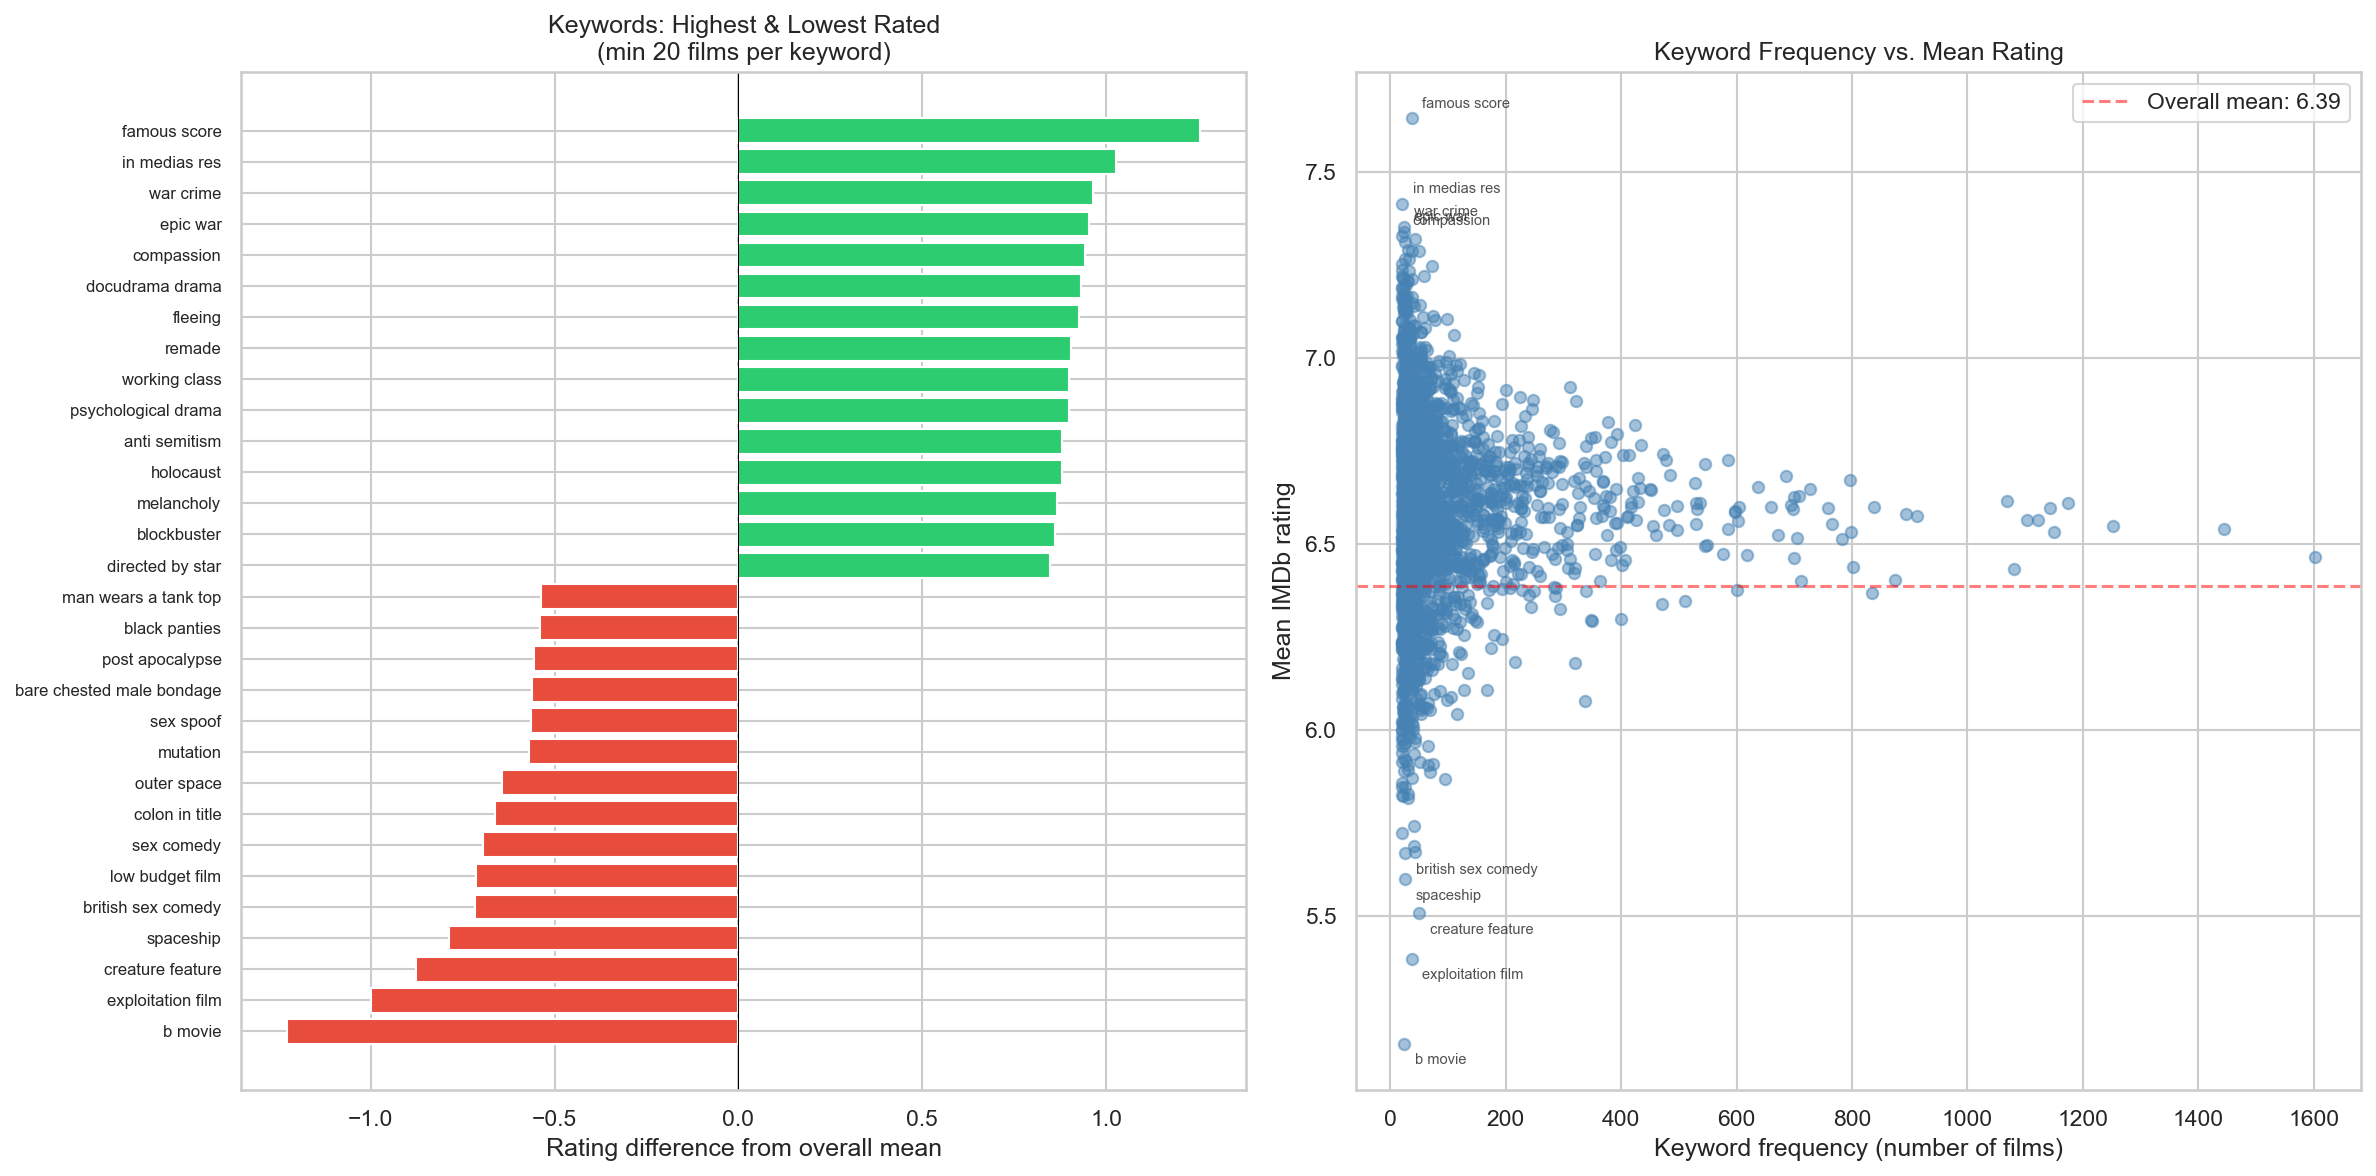


Rating spread across keywords: 5.16 — 7.64
Standard deviation of keyword mean ratings: 0.262


In [4]:
# Visualization: highest/lowest rated keywords + scatter of frequency vs rating
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: top 15 highest + top 15 lowest rated keywords
top_kw = kw_df.head(15)
bottom_kw = kw_df.tail(15)
combined = pd.concat([top_kw, bottom_kw])
colors = ['#2ecc71' if d > 0 else '#e74c3c' for d in combined['delta']]

axes[0].barh(range(len(combined)), combined['delta'], color=colors)
axes[0].set_yticks(range(len(combined)))
axes[0].set_yticklabels(combined['keyword'], fontsize=8)
axes[0].axvline(0, color='black', linewidth=0.5)
axes[0].set_xlabel('Rating difference from overall mean')
axes[0].set_title('Keywords: Highest & Lowest Rated\n(min 20 films per keyword)')
axes[0].invert_yaxis()

# Right: scatter — keyword frequency vs mean rating
axes[1].scatter(kw_df['frequency'], kw_df['mean_rating'], alpha=0.5, s=30, color='steelblue')
axes[1].axhline(overall_mean_rating, color='red', linestyle='--', alpha=0.5, label=f'Overall mean: {overall_mean_rating:.2f}')
axes[1].set_xlabel('Keyword frequency (number of films)')
axes[1].set_ylabel('Mean IMDb rating')
axes[1].set_title('Keyword Frequency vs. Mean Rating')
axes[1].legend()

# Annotate a few outliers
for _, row in kw_df.head(5).iterrows():
    axes[1].annotate(row['keyword'], (row['frequency'], row['mean_rating']),
                     fontsize=7, alpha=0.8, xytext=(5, 5), textcoords='offset points')
for _, row in kw_df.tail(5).iterrows():
    axes[1].annotate(row['keyword'], (row['frequency'], row['mean_rating']),
                     fontsize=7, alpha=0.8, xytext=(5, -10), textcoords='offset points')

plt.tight_layout()
save_figure(fig, 'direction_keywords_rating')
plt.show()

print(f"\nRating spread across keywords: {kw_df['mean_rating'].min():.2f} — {kw_df['mean_rating'].max():.2f}")
print(f"Standard deviation of keyword mean ratings: {kw_df['mean_rating'].std():.3f}")

### Verdict: Keywords → Rating

**Findings:** *(fill in after running)*

**Richness:** 56,000+ unique keywords — enormous granularity, but many are too rare to be reliable.
**Course alignment:** Keywords are user-generated (connects to datafication — structuring moment). Connects to Publikum's PlotBounce thematic clusters.
**Feasibility:** Medium — need careful filtering to avoid noise from rare keywords.

**Should we explore further?** *(fill in after running)*

---

## 2. Actor/Actress Combinations → Rating

**Question:** Do certain actors or actor pairs correlate with higher ratings?

If some actors consistently appear in high-rated films, or if certain actor pairings produce better results, that could inform casting and project positioning advice.

In [5]:
# Parse topFiveActors to extract actor IMDb IDs and names
def parse_actors(actor_string):
    """Extract list of (imdb_id, character_name) tuples from topFiveActors."""
    if pd.isna(actor_string):
        return []
    return re.findall(r'(nm\d+)\s*\(([^)]+)\)', actor_string)

# Build actor-level DataFrame: one row per actor-movie combination
actor_rows = []
for _, row in df.iterrows():
    for actor_id, char_name in parse_actors(row['topFiveActors']):
        actor_rows.append({
            'titleId': row['titleId'],
            'actor_id': actor_id,
            'character_name': char_name.strip(),
            'imdbRating': row['imdbRating'],
            'numberOfVotes': row['numberOfVotes'],
            'genres': row['genres'],
            'originalTitle': row['originalTitle']
        })
actor_df = pd.DataFrame(actor_rows)

# Actors who appear in 3+ films
actor_counts = actor_df.groupby('actor_id').agg(
    film_count=('titleId', 'nunique'),
    mean_rating=('imdbRating', 'mean'),
    total_votes=('numberOfVotes', 'sum'),
    sample_name=('character_name', 'first')
).reset_index()

repeat_actors = actor_counts[actor_counts['film_count'] >= 3].sort_values('mean_rating', ascending=False)

print(f"Total actor appearances: {len(actor_df):,}")
print(f"Unique actors: {actor_df['actor_id'].nunique():,}")
print(f"Actors in 3+ films: {len(repeat_actors)}")
print(f"\nTop 15 repeat actors by mean rating:")
print(repeat_actors.head(15)[['actor_id', 'film_count', 'mean_rating', 'total_votes']].to_string(index=False))

Total actor appearances: 9,933
Unique actors: 6,889
Actors in 3+ films: 599

Top 15 repeat actors by mean rating:
 actor_id  film_count  mean_rating  total_votes
nm0000142           3     8.366667      1947594
nm0085038           3     8.033333       280034
nm0477810           3     7.966667       777201
nm0487884           4     7.850000      1295878
nm0417837           3     7.833333        50439
nm0167388           3     7.833333      1022463
nm0685559           4     7.800000      1150631
nm0000852           3     7.766667       258469
nm0000416           4     7.750000       755466
nm2588665           4     7.700000       323743
nm0000761           3     7.700000       254238
nm0618057           3     7.666667       528727
nm0603402           3     7.633333        33322
nm0001812           4     7.625000      1284713
nm0893341           4     7.600000        28351


Saved reports/figures/direction_actor_ratings.png


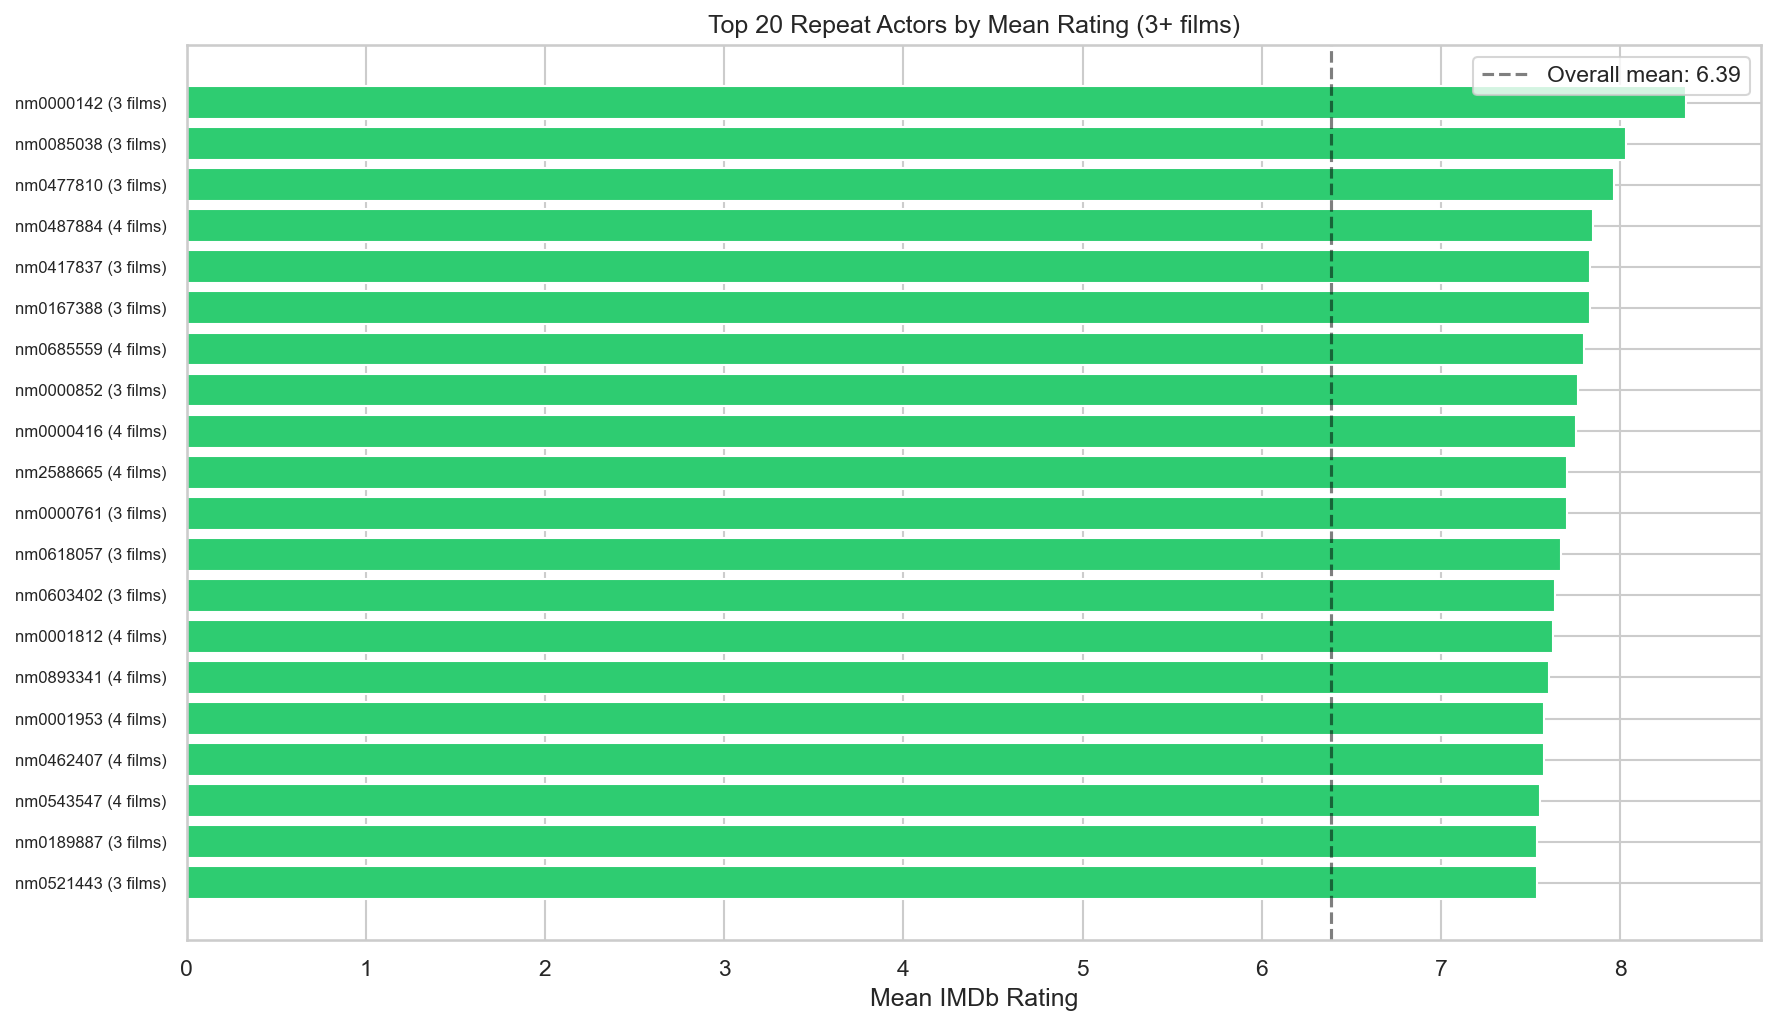


Actor pairs appearing in 2+ films: 1237

Top 10 actor pairs by mean rating:
                  pair  count  mean_rating
(nm0001812, nm0685559)      2          8.5
(nm0000142, nm0685559)      2          8.5
(nm0000142, nm0001812)      2          8.5
(nm0004486, nm0477810)      2          8.2
(nm0004486, nm0559890)      2          8.2
(nm0004486, nm0487884)      2          8.2
(nm0487884, nm0559890)      2          8.2
(nm0477810, nm0559890)      2          8.2
(nm0362896, nm0559890)      2          8.2
(nm0362896, nm0487884)      2          8.2


In [6]:
# Visualization: top repeat actors + actor pair analysis
fig, ax = plt.subplots(figsize=(12, 7))

top_actors = repeat_actors.head(20)
colors = ['#2ecc71' if r > overall_mean_rating else '#e74c3c' for r in top_actors['mean_rating']]
bars = ax.barh(range(len(top_actors)), top_actors['mean_rating'], color=colors)
ax.set_yticks(range(len(top_actors)))
ax.set_yticklabels([f"{row['actor_id']} ({row['film_count']} films)" for _, row in top_actors.iterrows()], fontsize=8)
ax.axvline(overall_mean_rating, color='black', linestyle='--', alpha=0.5, label=f'Overall mean: {overall_mean_rating:.2f}')
ax.set_xlabel('Mean IMDb Rating')
ax.set_title('Top 20 Repeat Actors by Mean Rating (3+ films)')
ax.legend()
ax.invert_yaxis()

plt.tight_layout()
save_figure(fig, 'direction_actor_ratings')
plt.show()

# Actor pairs: find pairs who co-appear in 2+ films
pair_rows = []
for title_id, group in actor_df.groupby('titleId'):
    actors = group['actor_id'].tolist()
    rating = group['imdbRating'].iloc[0]
    for a1, a2 in combinations(actors, 2):
        pair_key = tuple(sorted([a1, a2]))
        pair_rows.append({'pair': pair_key, 'rating': rating})

pair_df = pd.DataFrame(pair_rows)
pair_stats = pair_df.groupby('pair').agg(count=('rating', 'count'), mean_rating=('rating', 'mean')).reset_index()
repeat_pairs = pair_stats[pair_stats['count'] >= 2].sort_values('mean_rating', ascending=False)

print(f"\nActor pairs appearing in 2+ films: {len(repeat_pairs)}")
print(f"\nTop 10 actor pairs by mean rating:")
print(repeat_pairs.head(10).to_string(index=False))

### Verdict: Actor/Actress Combinations → Rating

**Findings:** *(fill in after running)*

**Richness:** Depends on how many actors appear 3+ times — if it's sparse, patterns are unreliable.
**Course alignment:** Could connect to network analysis (actor collaboration networks, VNA). But actor identity is less tied to course frameworks than thematic or market-level analysis.
**Feasibility:** Medium — limited by data sparsity (most actors probably appear only once).

**Should we explore further?** *(fill in after running)*

---

## 3. What Makes a Film "Travel"? — Breakout Analysis

**Question:** What features do films that achieve both high ratings AND high visibility share?

We define "breakout" films as those above the median in both rating and vote count — films that are both well-received and widely seen. If we can profile what makes them different, that's directly actionable for Publikum's positioning advice.

In [7]:
# Define breakout films: above-median rating AND above-median votes
df['is_breakout'] = (df['imdbRating'] >= overall_median_rating) & (df['numberOfVotes'] >= overall_median_votes)

breakout = df[df['is_breakout']]
non_breakout = df[~df['is_breakout']]

print(f"Breakout films: {len(breakout)} ({len(breakout)/len(df)*100:.1f}%)")
print(f"Non-breakout:   {len(non_breakout)} ({len(non_breakout)/len(df)*100:.1f}%)")

# Profile comparison
print(f"\n{'Feature':<25} {'Breakout':>12} {'Non-breakout':>14}")
print("-" * 55)
print(f"{'Mean rating':<25} {breakout['imdbRating'].mean():>12.2f} {non_breakout['imdbRating'].mean():>14.2f}")
print(f"{'Mean votes':<25} {breakout['numberOfVotes'].mean():>12,.0f} {non_breakout['numberOfVotes'].mean():>14,.0f}")
print(f"{'Mean runtime (min)':<25} {breakout['runtimeMinutes'].mean():>12.1f} {non_breakout['runtimeMinutes'].mean():>14.1f}")
print(f"{'Co-production rate':<25} {breakout['is_coproduction'].mean()*100:>11.1f}% {non_breakout['is_coproduction'].mean()*100:>13.1f}%")
print(f"{'Mean genre count':<25} {breakout['genre_count'].mean():>12.2f} {non_breakout['genre_count'].mean():>14.2f}")
print(f"{'Mean keyword count':<25} {breakout['keyword_count'].mean():>12.1f} {non_breakout['keyword_count'].mean():>14.1f}")

# Top genres in breakout vs overall
print(f"\nTop genres in breakout films:")
breakout_genres = split_field(breakout['genres']).value_counts().head(8)
all_genres = split_field(df['genres']).value_counts()
for genre, count in breakout_genres.items():
    pct_breakout = count / len(breakout) * 100
    pct_all = all_genres.get(genre, 0) / len(df) * 100
    enrichment = pct_breakout / pct_all if pct_all > 0 else 0
    print(f"  {genre:<15} {pct_breakout:5.1f}% of breakout vs {pct_all:5.1f}% overall  (enrichment: {enrichment:.2f}x)")

Breakout films: 657 (32.9%)
Non-breakout:   1343 (67.2%)

Feature                       Breakout   Non-breakout
-------------------------------------------------------
Mean rating                       7.24           5.97
Mean votes                     128,740         17,226
Mean runtime (min)               114.4           99.4
Co-production rate               79.1%          54.9%
Mean genre count                  3.04           2.83
Mean keyword count               199.1           99.7

Top genres in breakout films:
  Drama            73.5% of breakout vs  59.4% overall  (enrichment: 1.24x)
  Thriller         31.2% of breakout vs  31.4% overall  (enrichment: 0.99x)
  Comedy           24.8% of breakout vs  26.5% overall  (enrichment: 0.94x)
  Romance          22.7% of breakout vs  20.6% overall  (enrichment: 1.10x)
  Crime            21.2% of breakout vs  16.6% overall  (enrichment: 1.28x)
  Adventure        16.4% of breakout vs  16.7% overall  (enrichment: 0.99x)
  Action           14

Saved reports/figures/direction_breakout_analysis.png


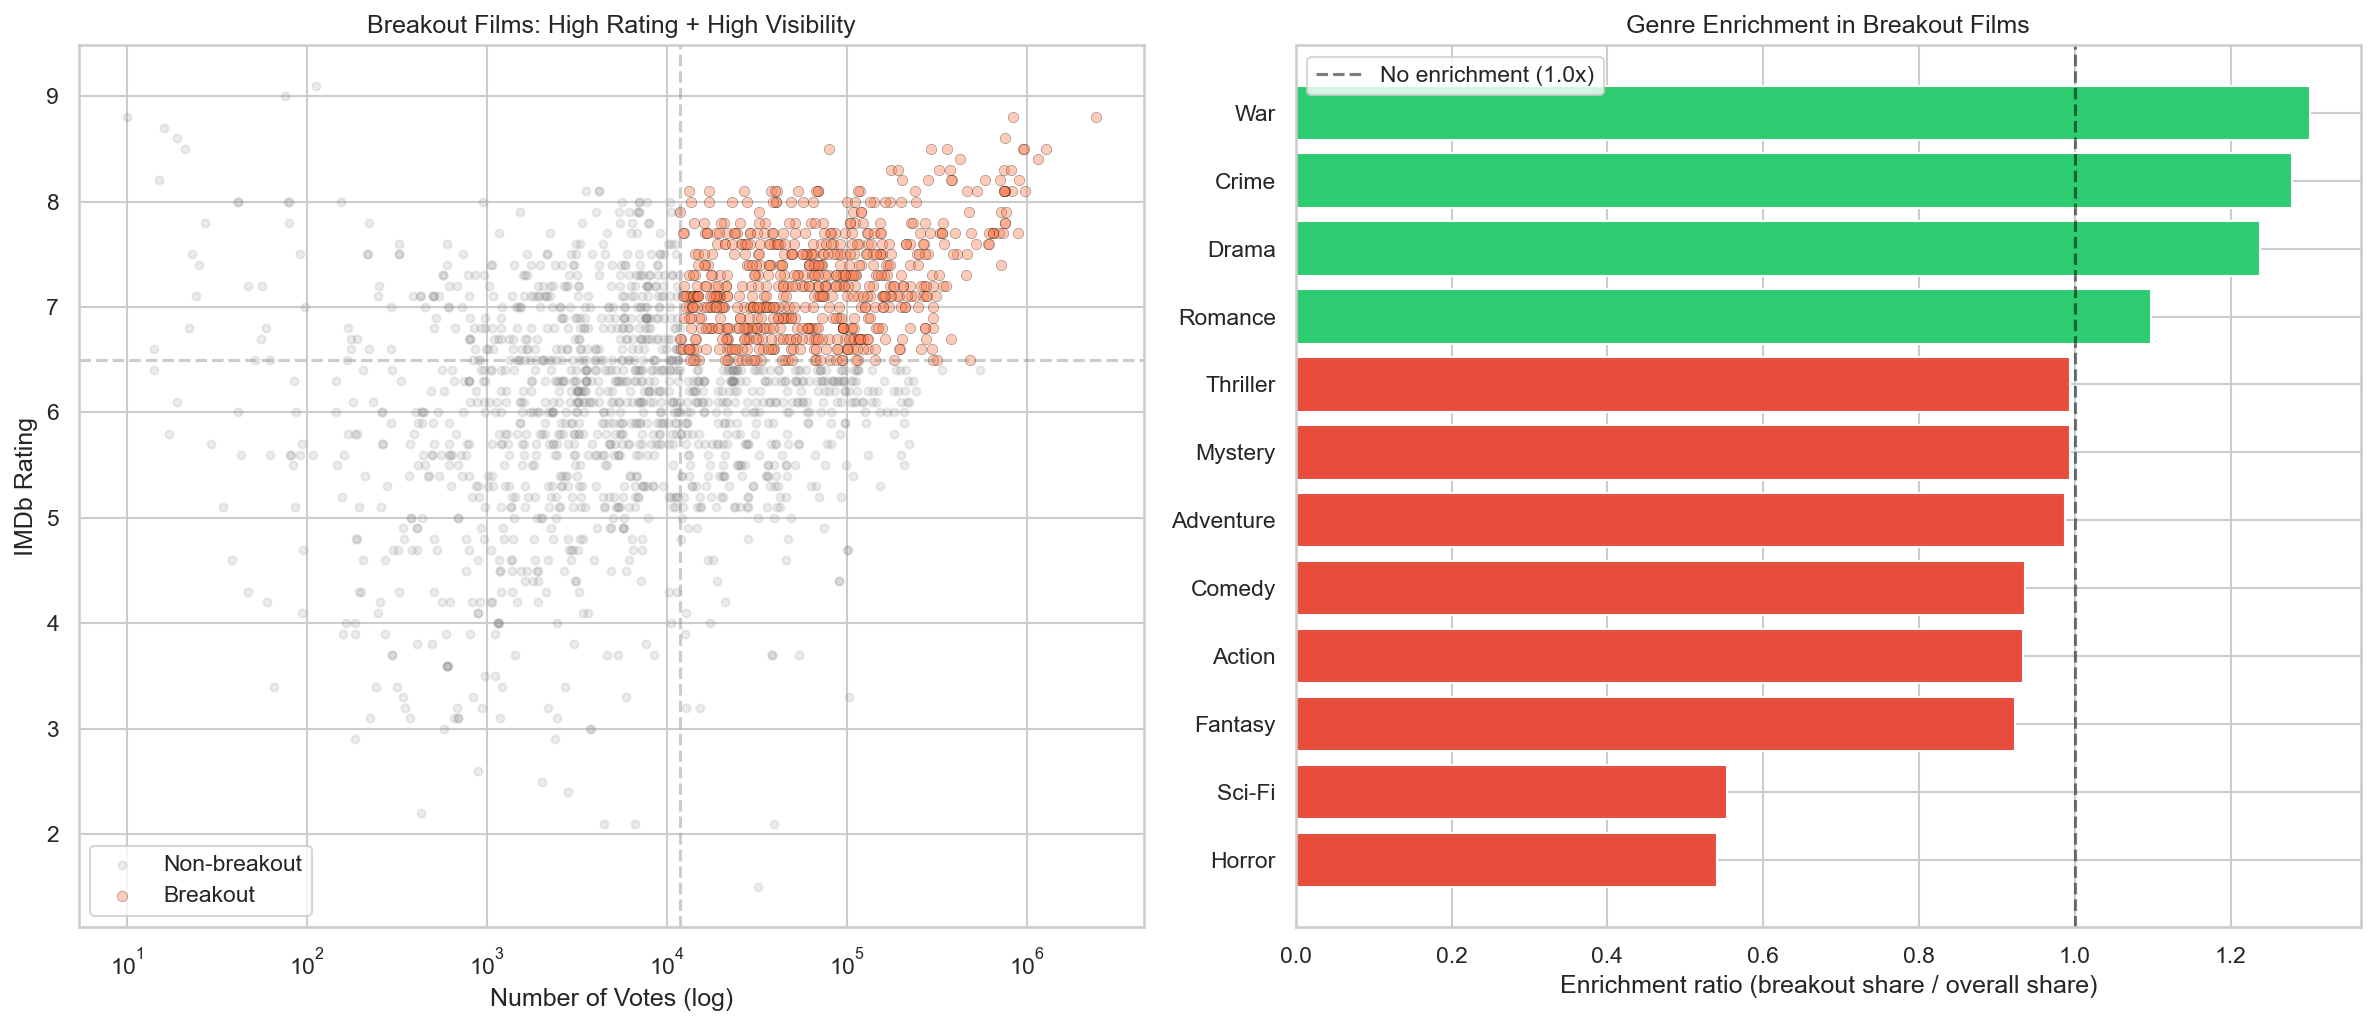

In [8]:
# Visualization: breakout scatter + genre enrichment
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: scatter with breakout highlighted
axes[0].scatter(non_breakout['numberOfVotes'], non_breakout['imdbRating'],
                alpha=0.15, s=15, color='gray', label='Non-breakout')
axes[0].scatter(breakout['numberOfVotes'], breakout['imdbRating'],
                alpha=0.4, s=25, color='coral', label='Breakout', edgecolors='black', linewidths=0.3)
axes[0].axhline(overall_median_rating, color='gray', linestyle='--', alpha=0.4)
axes[0].axvline(overall_median_votes, color='gray', linestyle='--', alpha=0.4)
axes[0].set_xscale('log')
axes[0].set_xlabel('Number of Votes (log)')
axes[0].set_ylabel('IMDb Rating')
axes[0].set_title('Breakout Films: High Rating + High Visibility')
axes[0].legend()

# Right: genre enrichment in breakout films
top_genres_list = split_field(df['genres']).value_counts().head(12).index
enrichment_data = []
for genre in top_genres_list:
    pct_breakout = (breakout['genres'].str.contains(genre, na=False).sum() / len(breakout)) * 100
    pct_all = (df['genres'].str.contains(genre, na=False).sum() / len(df)) * 100
    enrichment_data.append({'genre': genre, 'enrichment': pct_breakout / pct_all if pct_all > 0 else 0})

enrich_df = pd.DataFrame(enrichment_data).sort_values('enrichment', ascending=True)
colors = ['#2ecc71' if e >= 1 else '#e74c3c' for e in enrich_df['enrichment']]
axes[1].barh(enrich_df['genre'], enrich_df['enrichment'], color=colors)
axes[1].axvline(1.0, color='black', linestyle='--', alpha=0.5, label='No enrichment (1.0x)')
axes[1].set_xlabel('Enrichment ratio (breakout share / overall share)')
axes[1].set_title('Genre Enrichment in Breakout Films')
axes[1].legend()

plt.tight_layout()
save_figure(fig, 'direction_breakout_analysis')
plt.show()

### Verdict: Breakout Analysis

**Findings:** *(fill in after running)*

**Richness:** High — combines multiple features (genre, country, co-production, runtime, keywords) into one framework.
**Course alignment:** Strong — directly actionable for Publikum ("what predicts a film that travels?"). Connects to data as tool (Xu et al.), datafication visualization moment, and organizational decision-making.
**Feasibility:** High — uses existing columns, no external data needed.

**Should we explore further?** *(fill in after running)*

---

## 4. Plot-Based Thematic Clustering (NLP)

**Question:** Can we cluster films by narrative content using plot descriptions? Do clusters reveal groupings beyond genre labels?

Genre labels like "Drama" are broad. The plot summaries might reveal finer-grained thematic groupings — a simplified version of what Publikum's PlotBounce tool does with "expectation clusters."

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Use plotMedium; fall back to plotShort if missing
plot_col = 'plotMedium'
plot_data = df.dropna(subset=[plot_col]).copy()
print(f"Films with {plot_col}: {len(plot_data)} / {len(df)}")

# TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=1000, stop_words='english', min_df=5, max_df=0.7)
tfidf_matrix = tfidf.fit_transform(plot_data[plot_col])
print(f"TF-IDF matrix: {tfidf_matrix.shape[0]} films x {tfidf_matrix.shape[1]} features")

# KMeans clustering with k=8
k = 8
km = KMeans(n_clusters=k, random_state=42, n_init=10)
plot_data['cluster'] = km.fit_predict(tfidf_matrix)

# Top terms per cluster
feature_names = tfidf.get_feature_names_out()
print(f"\nTop 10 terms per cluster:")
for i in range(k):
    top_indices = km.cluster_centers_[i].argsort()[-10:][::-1]
    top_terms = [feature_names[j] for j in top_indices]
    count = (plot_data['cluster'] == i).sum()
    print(f"  Cluster {i} (n={count}): {', '.join(top_terms)}")

Films with plotMedium: 2000 / 2000
TF-IDF matrix: 2000 films x 1000 features

Top 10 terms per cluster:
  Cluster 0 (n=267): film, town, family, brother, story, life, world, children, money, star
  Cluster 1 (n=587): world, police, people, soon, dr, evil, killer, new, time, death
  Cluster 2 (n=88): school, high, girl, teacher, mother, students, boy, old, boys, new
  Cluster 3 (n=222): war, british, german, world, army, ii, prison, mission, team, soldiers
  Cluster 4 (n=302): man, young, woman, women, love, men, story, husband, named, life
  Cluster 5 (n=455): life, family, father, friends, old, love, year, mother, new, daughter
  Cluster 6 (n=54): count, castle, laura, dracula, vampire, mysterious, night, blood, van, wife
  Cluster 7 (n=25): jack, heart, greater, selling, point, experience, story, murder, ultimate, love


Saved reports/figures/direction_plot_clusters.png


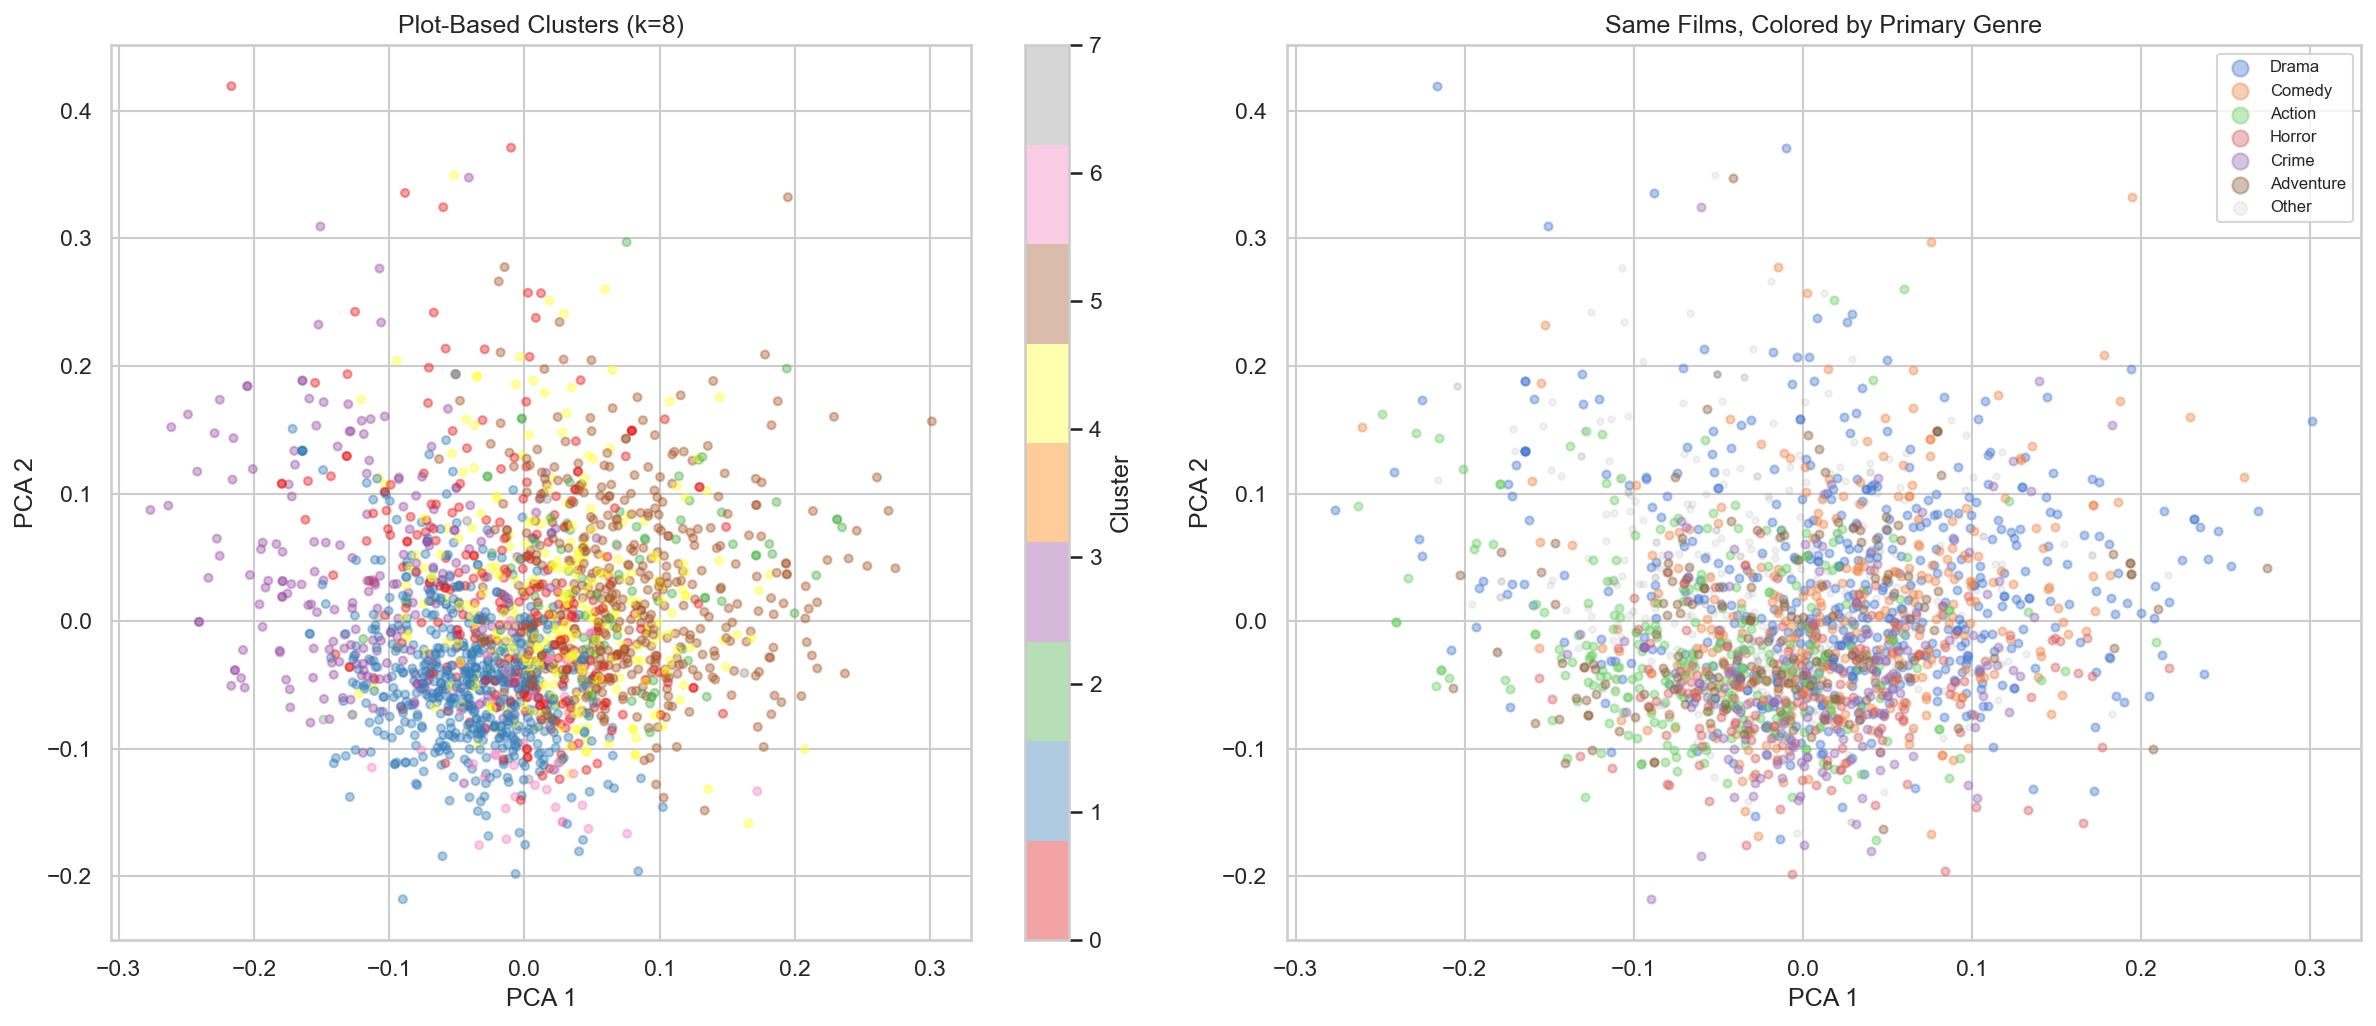

Saved reports/figures/direction_cluster_genre_heatmap.png


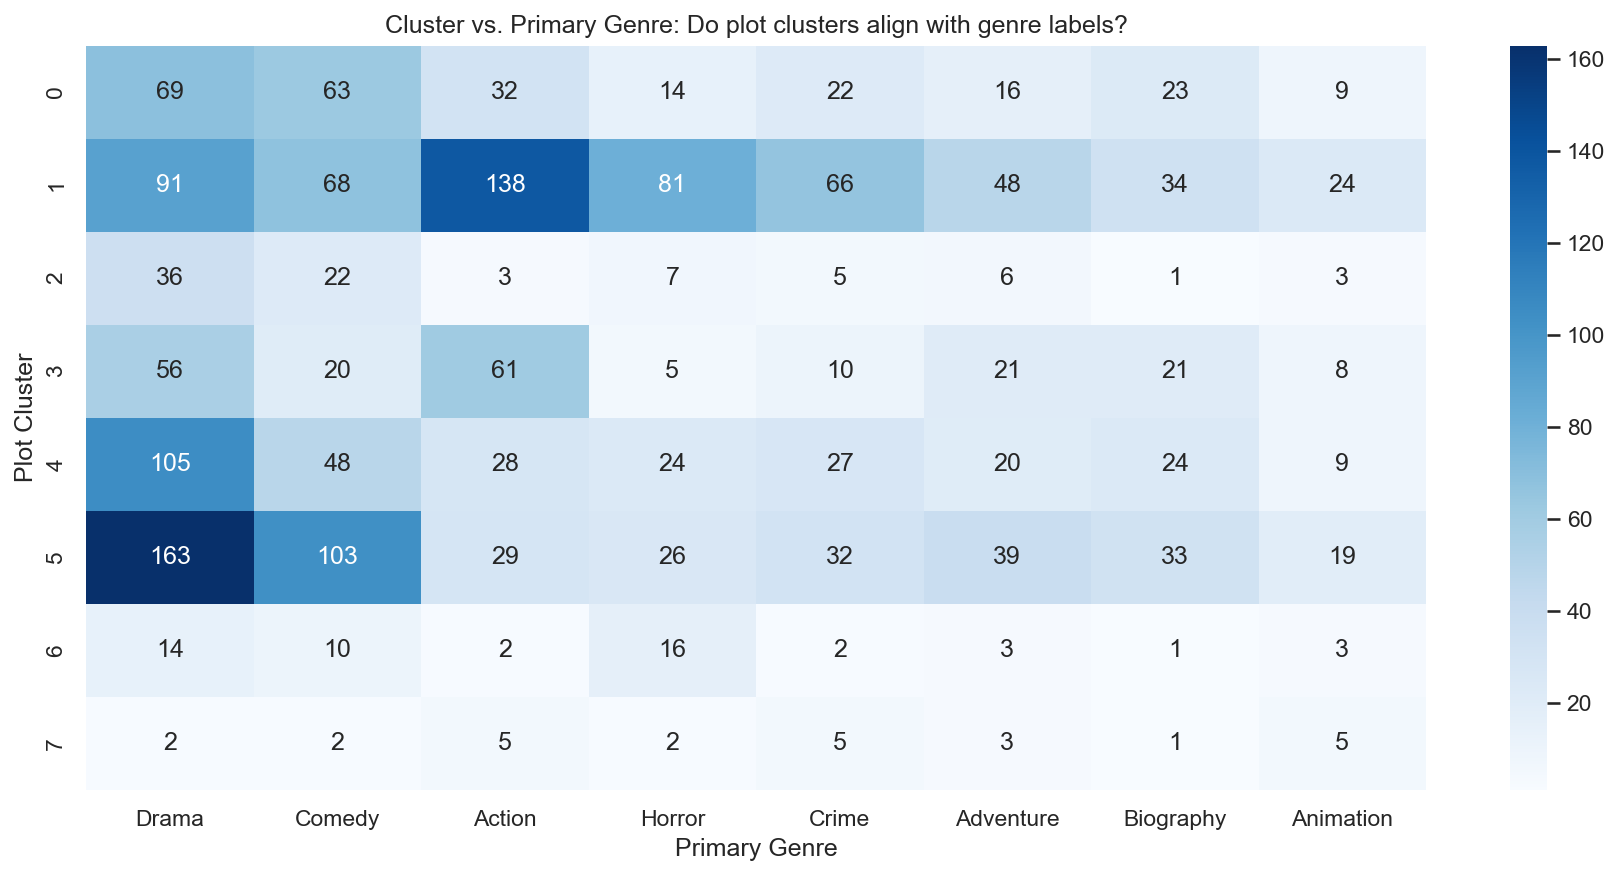

In [10]:
# PCA visualization: clusters vs genres side by side
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(tfidf_matrix.toarray())
plot_data['pca_x'] = coords[:, 0]
plot_data['pca_y'] = coords[:, 1]

# Primary genre (first listed genre)
plot_data['primary_genre'] = plot_data['genres'].str.split(', ').str[0]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: colored by cluster
scatter1 = axes[0].scatter(plot_data['pca_x'], plot_data['pca_y'],
                           c=plot_data['cluster'], cmap='Set1', alpha=0.4, s=15)
axes[0].set_title(f'Plot-Based Clusters (k={k})')
axes[0].set_xlabel('PCA 1')
axes[0].set_ylabel('PCA 2')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Right: colored by primary genre (top 6 genres only, rest gray)
top_6 = plot_data['primary_genre'].value_counts().head(6).index
genre_colors = {g: i for i, g in enumerate(top_6)}
plot_data['genre_color'] = plot_data['primary_genre'].map(genre_colors).fillna(-1)

for genre in top_6:
    mask = plot_data['primary_genre'] == genre
    axes[1].scatter(plot_data.loc[mask, 'pca_x'], plot_data.loc[mask, 'pca_y'],
                    alpha=0.4, s=15, label=genre)
other_mask = ~plot_data['primary_genre'].isin(top_6)
axes[1].scatter(plot_data.loc[other_mask, 'pca_x'], plot_data.loc[other_mask, 'pca_y'],
                alpha=0.1, s=10, color='gray', label='Other')
axes[1].set_title('Same Films, Colored by Primary Genre')
axes[1].set_xlabel('PCA 1')
axes[1].set_ylabel('PCA 2')
axes[1].legend(fontsize=8, markerscale=2)

plt.tight_layout()
save_figure(fig, 'direction_plot_clusters')
plt.show()

# Cluster vs genre crosstab
crosstab = pd.crosstab(plot_data['cluster'], plot_data['primary_genre'])
# Keep only top 8 genres for readability
top_8_genres = plot_data['primary_genre'].value_counts().head(8).index
crosstab = crosstab[top_8_genres]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Cluster vs. Primary Genre: Do plot clusters align with genre labels?')
ax.set_ylabel('Plot Cluster')
ax.set_xlabel('Primary Genre')
plt.tight_layout()
save_figure(fig, 'direction_cluster_genre_heatmap')
plt.show()

### Verdict: Plot-Based Clustering

**Findings:** *(fill in after running)*

**Richness:** Depends on whether TF-IDF on plot summaries gives meaningful separation or just noise.
**Course alignment:** Connects to datafication (structuring unstructured text), data as algorithmic intelligence (Xu et al.). Also directly mirrors Publikum's PlotBounce methodology.
**Feasibility:** Medium — requires NLP tuning, and short/medium plots may not contain enough signal.

**Should we explore further?** *(fill in after running)*

---

## 5. Genre White Space Analysis

**Question:** Are there genre-country combinations that are underserved — genres that perform well globally but are rare in certain markets?

If a genre rates well across Europe but barely exists in a specific country, that's a positioning opportunity Publikum could flag for clients.

Saved reports/figures/direction_genre_whitespace.png


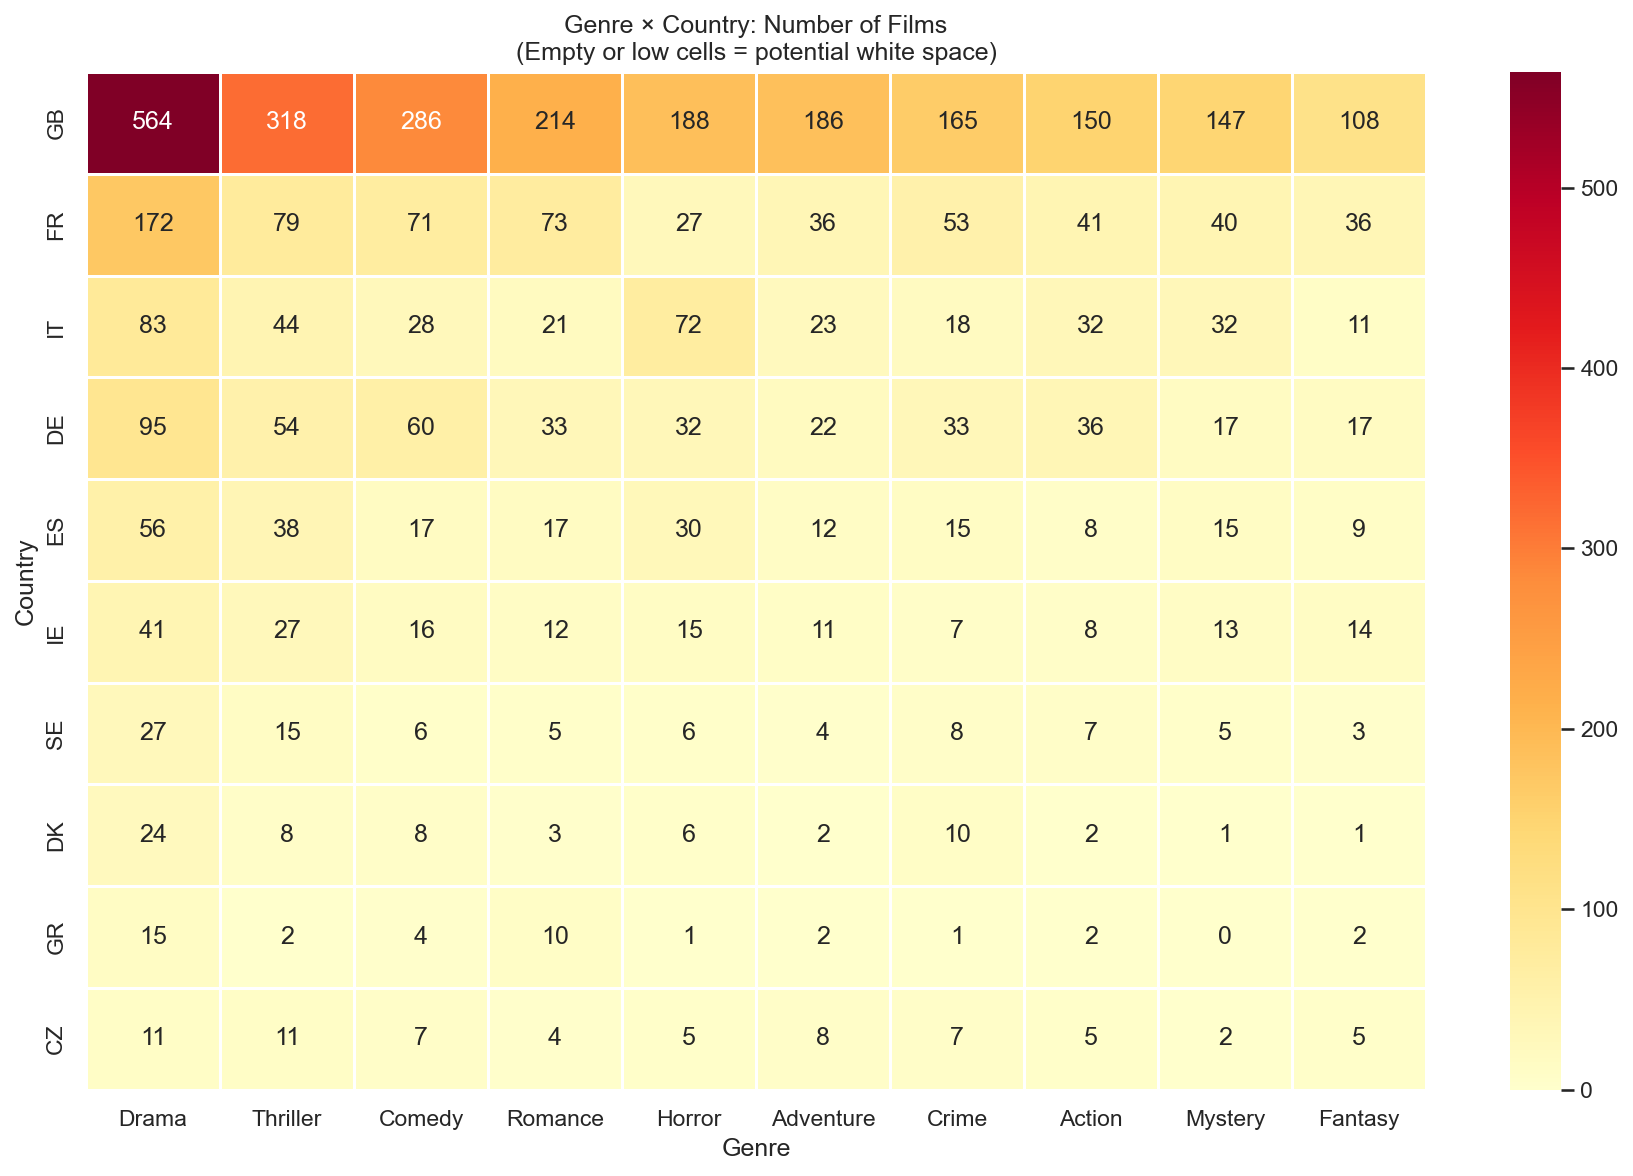


White space opportunities (≤2 films, genre rates above 6.39):

country genre  films_in_country  genre_global_rating
     GR Crime                 1                 6.53


In [11]:
# Genre x country matrix
top_countries = df['mainCountry'].value_counts().head(10).index.tolist()
top_genres = split_field(df['genres']).value_counts().head(10).index.tolist()

# Build count matrix
gc_matrix = pd.DataFrame(0, index=top_countries, columns=top_genres)
for _, row in df[df['mainCountry'].isin(top_countries)].iterrows():
    if pd.notna(row['genres']):
        for genre in row['genres'].split(', '):
            genre = genre.strip()
            if genre in top_genres:
                gc_matrix.loc[row['mainCountry'], genre] += 1

# Global mean rating per genre
genre_global_rating = {}
for genre in top_genres:
    mask = df['genres'].str.contains(genre, na=False)
    genre_global_rating[genre] = df.loc[mask, 'imdbRating'].mean()

# Heatmap
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(gc_matrix, annot=True, fmt='d', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Genre × Country: Number of Films\n(Empty or low cells = potential white space)')
ax.set_ylabel('Country')
ax.set_xlabel('Genre')
plt.tight_layout()
save_figure(fig, 'direction_genre_whitespace')
plt.show()

# Identify opportunities: cells with ≤2 films where genre rates above average
print(f"\nWhite space opportunities (≤2 films, genre rates above {overall_mean_rating:.2f}):\n")
opportunities = []
for country in top_countries:
    for genre in top_genres:
        count = gc_matrix.loc[country, genre]
        g_rating = genre_global_rating[genre]
        if count <= 2 and g_rating > overall_mean_rating:
            opportunities.append({
                'country': country, 'genre': genre,
                'films_in_country': count, 'genre_global_rating': round(g_rating, 2)
            })

opp_df = pd.DataFrame(opportunities).sort_values('genre_global_rating', ascending=False)
print(opp_df.to_string(index=False))

### Verdict: Genre White Space

**Findings:** *(fill in after running)*

**Richness:** Medium — limited by dataset size per country (small countries may show gaps simply because they have few films total, not because the genre is truly underserved).
**Course alignment:** Directly actionable for Publikum's market positioning. Connects to organizational affordances (Zammuto et al.) — what opportunities does the data make visible?
**Feasibility:** High — straightforward cross-tabulation.

**Should we explore further?** *(fill in after running)*

---

## 6. Language and Market Reach

**Question:** Do English-language or multilingual films get more visibility? Does language choice affect ratings?

Language is a key factor in whether a European film reaches beyond its home market. If we can quantify the "English premium" (or lack of it), that informs positioning strategy.

Saved reports/figures/direction_language_reach.png


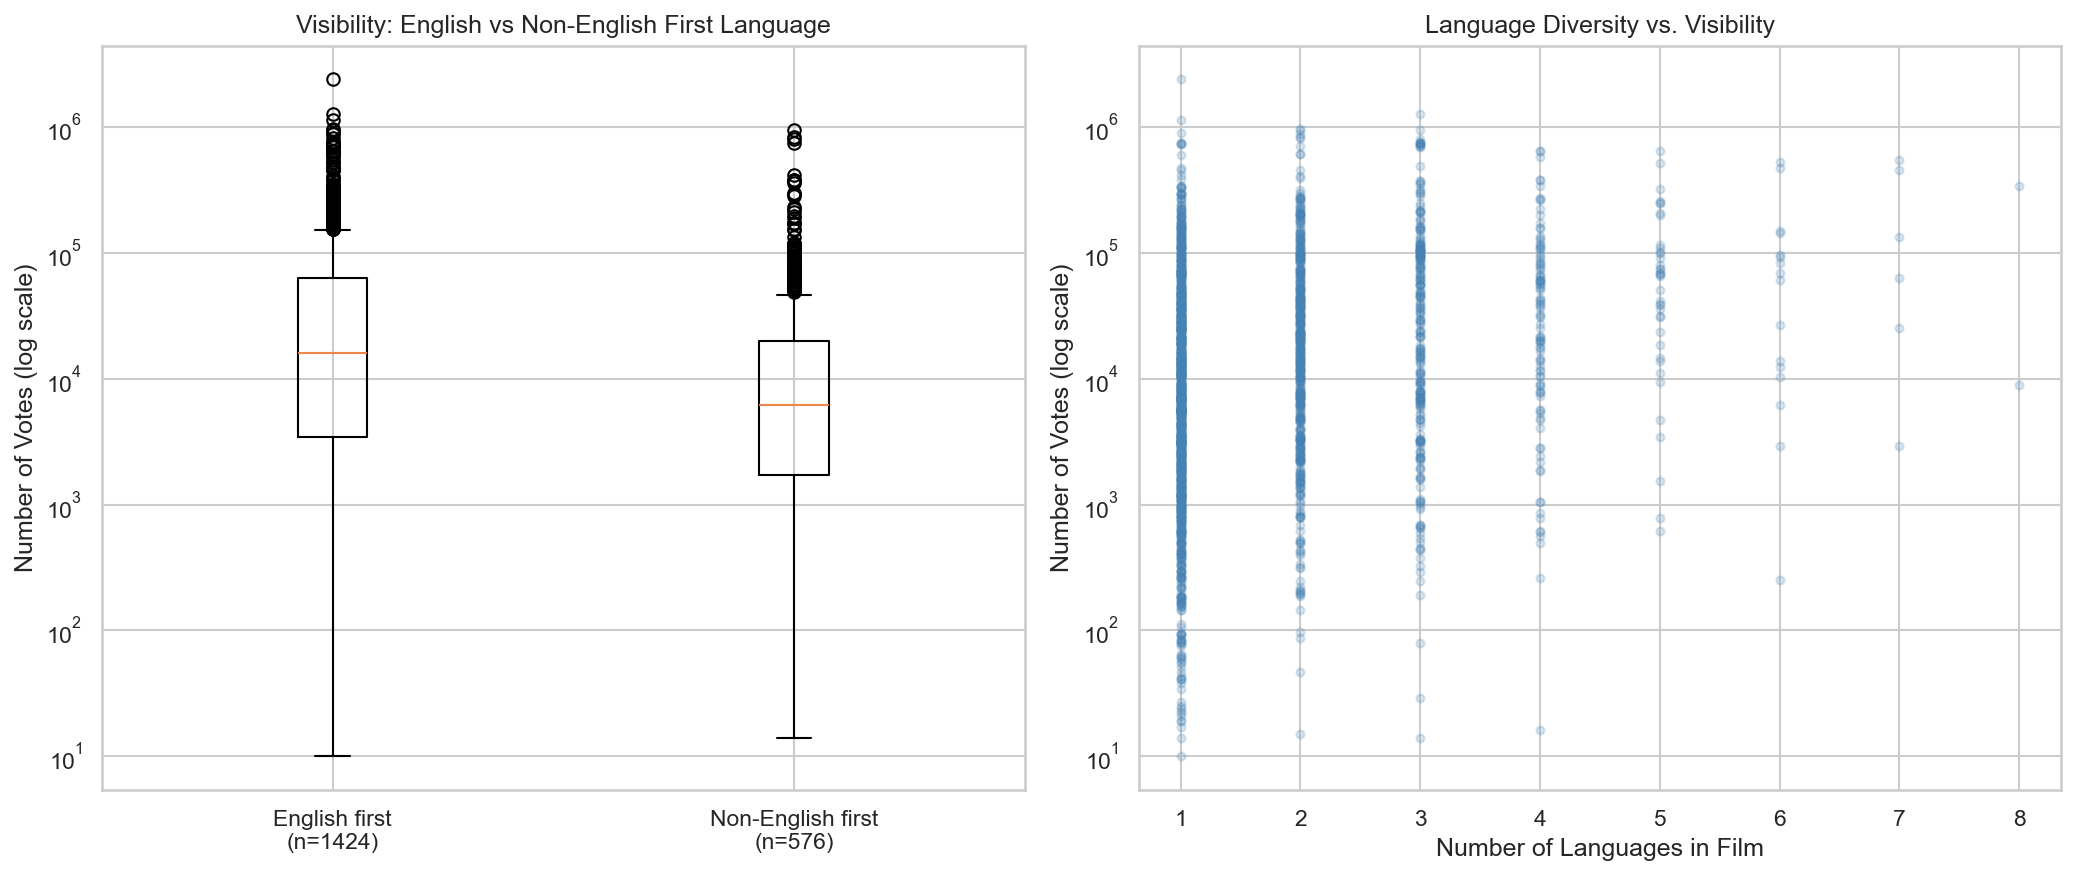


Category                   Mean Rating   Median Votes
-------------------------------------------------------
English first                     6.29         16,160
Non-English first                 6.63          6,201
Monolingual                       6.19          7,182
Multilingual                      6.65         22,066

By first language (10+ films):
firstLanguage  count  mean_rating  median_votes
           sv     25     6.884000       22948.0
           no     13     6.230769       16252.0
           en   1424     6.288904       16160.5
           de     58     6.925862       15439.0
           pl     18     6.488889       13332.5
           fr    164     6.768293        7949.5
           da     18     6.377778        7463.0
           es     54     6.337037        5164.0
           it    116     6.296552        3304.0
          zxx     10     6.720000        2998.0
           el     20     6.865000        2597.5


In [12]:
# Language analysis
df['is_english_first'] = df['firstLanguage'] == 'en'
df['is_multilingual'] = df['language_count'] > 1

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: votes by English vs non-English first language
en_votes = df[df['is_english_first']]['numberOfVotes']
non_en_votes = df[~df['is_english_first']]['numberOfVotes']
axes[0].boxplot([en_votes.dropna(), non_en_votes.dropna()],
                labels=[f'English first\n(n={len(en_votes)})', f'Non-English first\n(n={len(non_en_votes)})'])
axes[0].set_yscale('log')
axes[0].set_ylabel('Number of Votes (log scale)')
axes[0].set_title('Visibility: English vs Non-English First Language')

# Right: language count vs votes
axes[1].scatter(df['language_count'], df['numberOfVotes'], alpha=0.2, s=15, color='steelblue')
axes[1].set_yscale('log')
axes[1].set_xlabel('Number of Languages in Film')
axes[1].set_ylabel('Number of Votes (log scale)')
axes[1].set_title('Language Diversity vs. Visibility')

plt.tight_layout()
save_figure(fig, 'direction_language_reach')
plt.show()

# Summary stats
print(f"\n{'Category':<25} {'Mean Rating':>12} {'Median Votes':>14}")
print("-" * 55)
print(f"{'English first':<25} {df[df['is_english_first']]['imdbRating'].mean():>12.2f} {df[df['is_english_first']]['numberOfVotes'].median():>14,.0f}")
print(f"{'Non-English first':<25} {df[~df['is_english_first']]['imdbRating'].mean():>12.2f} {df[~df['is_english_first']]['numberOfVotes'].median():>14,.0f}")
print(f"{'Monolingual':<25} {df[~df['is_multilingual']]['imdbRating'].mean():>12.2f} {df[~df['is_multilingual']]['numberOfVotes'].median():>14,.0f}")
print(f"{'Multilingual':<25} {df[df['is_multilingual']]['imdbRating'].mean():>12.2f} {df[df['is_multilingual']]['numberOfVotes'].median():>14,.0f}")

# By first language (10+ films)
lang_stats = df.groupby('firstLanguage').agg(
    count=('imdbRating', 'count'),
    mean_rating=('imdbRating', 'mean'),
    median_votes=('numberOfVotes', 'median')
).reset_index()
lang_stats = lang_stats[lang_stats['count'] >= 10].sort_values('median_votes', ascending=False)
print(f"\nBy first language (10+ films):")
print(lang_stats.to_string(index=False))

### Verdict: Language and Market Reach

**Findings:** *(fill in after running)*

**Richness:** Medium — language is only one proxy for market reach, and the IMDb English-speaker bias confounds the signal.
**Course alignment:** Connects to datafication production moment (IMDb's English-speaking user base) and critical data awareness (Mejias & Couldry).
**Feasibility:** High — simple groupby analysis.

**Should we explore further?** *(fill in after running)*

---

## 7. Co-Production Success by Country Pair

**Question:** Which specific country pairings produce better-rated or more visible films?

The general analysis showed co-productions exist. Here we go deeper: which partnerships actually work best?

Saved reports/figures/direction_coprod_pairs.png


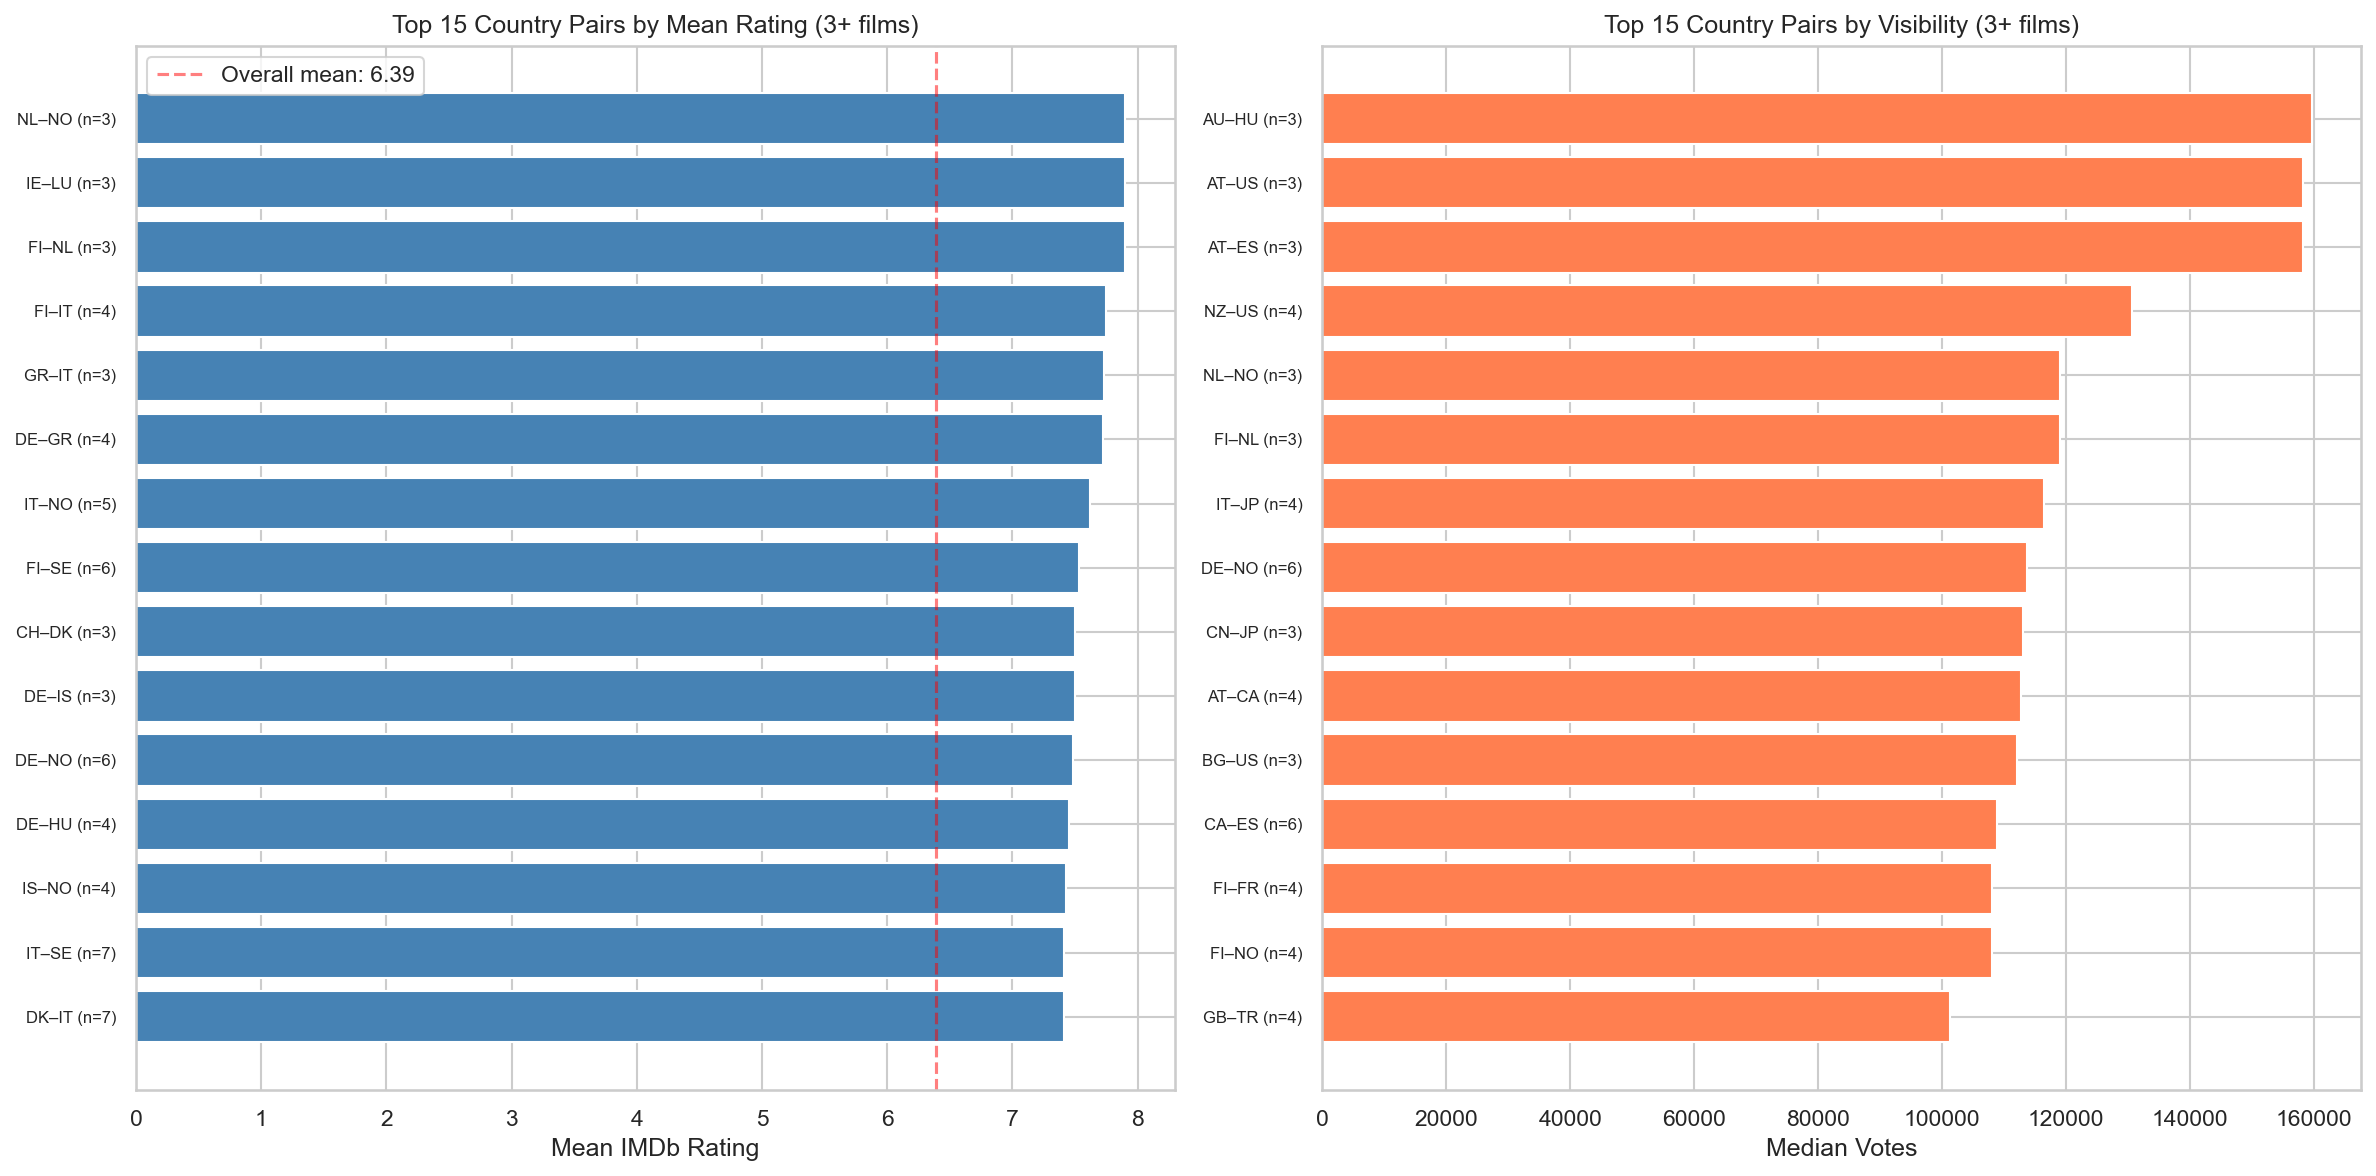


Country pairs with 3+ co-productions: 206

Full table:
  pair  count  mean_rating  median_votes
 NL–NO      3     7.900000      119023.0
 IE–LU      3     7.900000       40452.0
 FI–NL      3     7.900000      119023.0
 FI–IT      4     7.750000       96005.5
 GR–IT      3     7.733333        5401.0
 DE–GR      4     7.725000       31298.0
 IT–NO      5     7.620000       72988.0
 FI–SE      6     7.533333       54299.0
 CH–DK      3     7.500000       43789.0
 DE–IS      3     7.500000       72988.0
 DE–NO      6     7.483333      113767.5
 DE–HU      4     7.450000        8315.5
 IS–NO      4     7.425000       50146.5
 IT–SE      7     7.414286       69176.0
 DK–IT      7     7.414286       69176.0
 FI–NO      4     7.400000      108089.0
 IS–US      4     7.400000       96005.5
 GB–IS      4     7.400000       96005.5
 FI–FR      4     7.400000      108089.0
 FR–GR      7     7.400000       14566.0
 NO–SE     12     7.333333       71082.0
 DK–NL      5     7.280000       72988.0
 

In [13]:
# Build country-pair performance data
coprod_rows = []
for _, row in df[df['is_coproduction']].iterrows():
    countries = [c.strip() for c in row['allCountries'].split(', ')]
    for c1, c2 in combinations(countries, 2):
        pair_key = tuple(sorted([c1, c2]))
        coprod_rows.append({
            'pair': f"{pair_key[0]}–{pair_key[1]}",
            'rating': row['imdbRating'],
            'votes': row['numberOfVotes']
        })

cpair_df = pd.DataFrame(coprod_rows)
cpair_stats = cpair_df.groupby('pair').agg(
    count=('rating', 'count'),
    mean_rating=('rating', 'mean'),
    median_votes=('votes', 'median')
).reset_index()
cpair_stats = cpair_stats[cpair_stats['count'] >= 3].sort_values('mean_rating', ascending=False)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: top 15 pairs by mean rating
top_pairs = cpair_stats.head(15)
axes[0].barh(range(len(top_pairs)), top_pairs['mean_rating'], color='steelblue')
axes[0].set_yticks(range(len(top_pairs)))
axes[0].set_yticklabels([f"{row['pair']} (n={row['count']})" for _, row in top_pairs.iterrows()], fontsize=8)
axes[0].axvline(overall_mean_rating, color='red', linestyle='--', alpha=0.5, label=f'Overall mean: {overall_mean_rating:.2f}')
axes[0].set_xlabel('Mean IMDb Rating')
axes[0].set_title('Top 15 Country Pairs by Mean Rating (3+ films)')
axes[0].legend()
axes[0].invert_yaxis()

# Right: top 15 pairs by median votes
top_vis = cpair_stats.sort_values('median_votes', ascending=False).head(15)
axes[1].barh(range(len(top_vis)), top_vis['median_votes'], color='coral')
axes[1].set_yticks(range(len(top_vis)))
axes[1].set_yticklabels([f"{row['pair']} (n={row['count']})" for _, row in top_vis.iterrows()], fontsize=8)
axes[1].set_xlabel('Median Votes')
axes[1].set_title('Top 15 Country Pairs by Visibility (3+ films)')
axes[1].invert_yaxis()

plt.tight_layout()
save_figure(fig, 'direction_coprod_pairs')
plt.show()

print(f"\nCountry pairs with 3+ co-productions: {len(cpair_stats)}")
print(f"\nFull table:")
print(cpair_stats.to_string(index=False))

### Verdict: Co-Production Pairs

**Findings:** *(fill in after running)*

**Richness:** Depends on data density — how many pairs have 3+ films?
**Course alignment:** Strong VNA connection (network of co-production success). Directly actionable for Publikum's cross-market advisory work.
**Feasibility:** Medium — depends on having enough pairs to draw conclusions.

**Should we explore further?** *(fill in after running)*

---

## 8. Director Talent Patterns

**Question:** Do repeat directors show consistent quality? Do they specialize in genres? Do they bridge countries?

Directors are often the strongest signal of what a film will be. If certain directors consistently deliver, or if they bridge different European markets, that's relevant for positioning.

Unique directors: 1452
Directors with 3+ films: 144


Saved reports/figures/direction_director_patterns.png


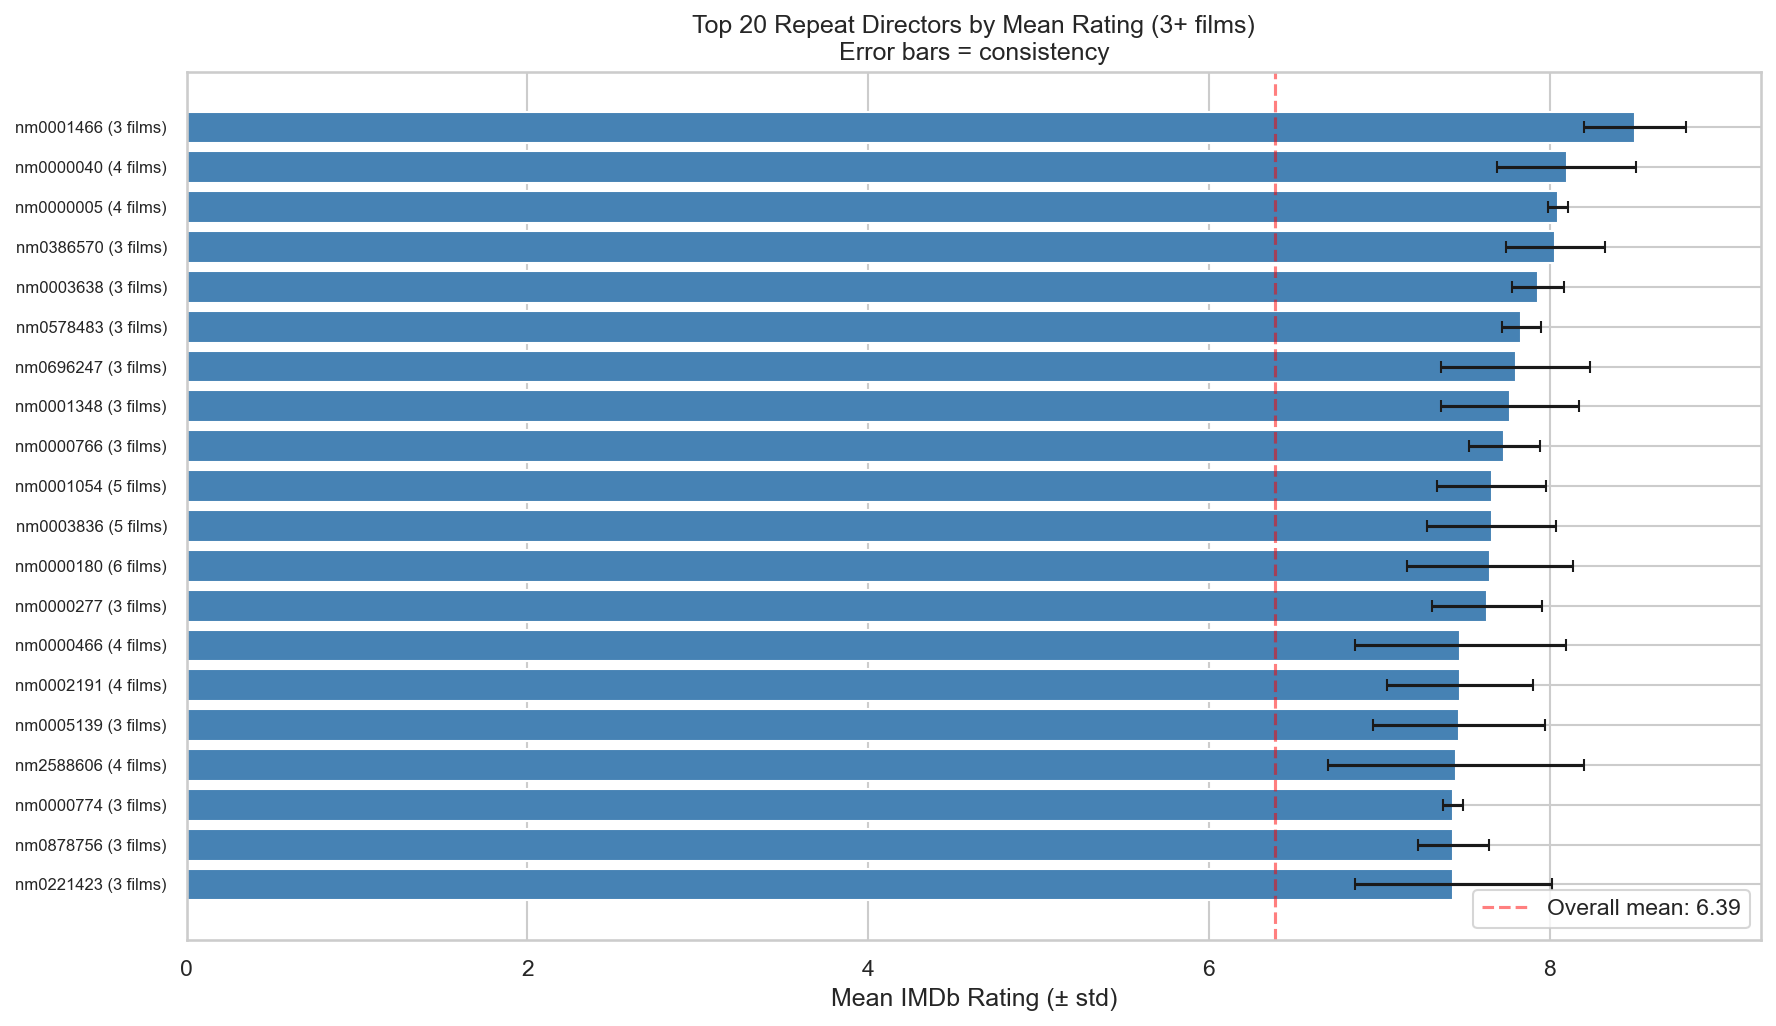


Bridge directors (films in 2+ countries): 45
  nm0000591: 8 films, countries: {'FR', 'CZ', 'GB'}, mean rating: 7.25
  nm0487166: 7 films, countries: {'GR', 'IE'}, mean rating: 6.87
  nm0001403: 7 films, countries: {'IE', 'GB'}, mean rating: 6.56
  nm0000108: 7 films, countries: {'FR', 'CZ'}, mean rating: 6.90
  nm0516360: 7 films, countries: {'IE', 'GB'}, mean rating: 7.24
  nm0359734: 6 films, countries: {'FR', 'AT'}, mean rating: 7.18
  nm0027271: 6 films, countries: {'CZ', 'GB', 'DE'}, mean rating: 5.67
  nm0001053: 6 films, countries: {'FR', 'GB'}, mean rating: 7.28
  nm1259871: 6 films, countries: {'FR', 'IE', 'GB'}, mean rating: 7.10
  nm0149446: 5 films, countries: {'FR', 'GB'}, mean rating: 6.64


In [14]:
# Parse directors and build director-level data
director_rows = []
for _, row in df.iterrows():
    if pd.notna(row['directors']):
        for d_id in row['directors'].split(', '):
            d_id = d_id.strip()
            director_rows.append({
                'director_id': d_id,
                'titleId': row['titleId'],
                'originalTitle': row['originalTitle'],
                'imdbRating': row['imdbRating'],
                'numberOfVotes': row['numberOfVotes'],
                'genres': row['genres'],
                'mainCountry': row['mainCountry']
            })
dir_df = pd.DataFrame(director_rows)

# Directors with 3+ films
dir_stats = dir_df.groupby('director_id').agg(
    film_count=('titleId', 'nunique'),
    mean_rating=('imdbRating', 'mean'),
    std_rating=('imdbRating', 'std'),
    total_votes=('numberOfVotes', 'sum'),
    countries=('mainCountry', lambda x: set(x)),
    genres=('genres', lambda x: set(', '.join(x.dropna()).split(', ')))
).reset_index()
dir_stats['country_count'] = dir_stats['countries'].apply(len)
repeat_dirs = dir_stats[dir_stats['film_count'] >= 3].sort_values('mean_rating', ascending=False)

print(f"Unique directors: {dir_df['director_id'].nunique()}")
print(f"Directors with 3+ films: {len(repeat_dirs)}")

# Top 15 prolific directors with mean rating + consistency
fig, ax = plt.subplots(figsize=(12, 7))
top_dirs = repeat_dirs.head(20)
ax.barh(range(len(top_dirs)), top_dirs['mean_rating'], 
        xerr=top_dirs['std_rating'].fillna(0), color='steelblue', capsize=3)
ax.set_yticks(range(len(top_dirs)))
ax.set_yticklabels([f"{row['director_id']} ({row['film_count']} films)" 
                     for _, row in top_dirs.iterrows()], fontsize=8)
ax.axvline(overall_mean_rating, color='red', linestyle='--', alpha=0.5, 
           label=f'Overall mean: {overall_mean_rating:.2f}')
ax.set_xlabel('Mean IMDb Rating (± std)')
ax.set_title('Top 20 Repeat Directors by Mean Rating (3+ films)\nError bars = consistency')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
save_figure(fig, 'direction_director_patterns')
plt.show()

# Bridge directors: made films in 2+ countries
bridge_dirs = repeat_dirs[repeat_dirs['country_count'] >= 2].sort_values('film_count', ascending=False)
print(f"\nBridge directors (films in 2+ countries): {len(bridge_dirs)}")
for _, row in bridge_dirs.head(10).iterrows():
    print(f"  {row['director_id']}: {row['film_count']} films, "
          f"countries: {row['countries']}, mean rating: {row['mean_rating']:.2f}")

### Verdict: Director Patterns

**Findings:** *(fill in after running)*

**Richness:** Depends on how many directors have 3+ films. Could be thin.
**Course alignment:** Connects to invisible work (Justesen & Plesner) — directors as hidden connectors in the industry. Could build into a VNA network.
**Feasibility:** Depends on data density.

**Should we explore further?** *(fill in after running)*

---

## 9. Summary — Recommended Direction

### Ranking of Explored Directions

| # | Direction | Richness | Course Alignment | Actionability for Publikum | Feasibility | Overall |
|---|-----------|----------|-----------------|---------------------------|-------------|---------|
| 1 | Keywords → Rating | | | | | |
| 2 | Actor Combinations | | | | | |
| 3 | Breakout Analysis | | | | | |
| 4 | Plot Clustering (NLP) | | | | | |
| 5 | Genre White Space | | | | | |
| 6 | Language & Reach | | | | | |
| 7 | Co-Production Pairs | | | | | |
| 8 | Director Patterns | | | | | |

*Fill in after running all sections. Rate each: High / Medium / Low*

---

### Recommendation

**Primary direction:** *(fill in)*

**Why this direction:**
- Richness of findings: ...
- Framework alignment: ...
- Actionability: ...
- Feasibility: ...

**Secondary direction (complement):** *(fill in — ideally one that pairs well, e.g. a network analysis direction to complement a statistical one)*

**Directions to drop:** *(fill in with brief reason for each)*

---

### Next steps

1. Create a dedicated deep-dive notebook for the chosen direction
2. Apply full course framework analysis (datafication moments, data value typology, invisible work)
3. Build the explanatory visualization for the pitch
4. Prepare stakeholder-facing narrative for Publikum